# Laboratorio 9: Proceso ETL - Mini Data WareHouse - Graficos

Bienvenido al Laboratorio 9. En esta sesión construiremos un pipeline de datos que extrae información real de **IMDb** mediante Web Scraping y la integra con datos sintéticos generados con **Faker**. Aprenderás a gestionar el ciclo de vida del dato desde su estado crudo hasta su carga en un Mini Data Warehouse y la visualización de gráficos.

## 📋 Tabla de Contenidos

1. [Introducción al Proceso ETL](#-introduccion)
2. [Configuración de Infraestructura de Carpetas](#-setup)
3. [Fuente 1: Web Scraping IMDb (Extracción y Limpieza)](#-fuente1)
4. [Fuente 2: Generación de Visitantes con Faker](#-fuente2)
5. [Integración y Transformación Final](#-union)
6. [Carga en Mini Data Warehouse (SQLite3)](#-warehouse)
7. [Visualizaciones: BI desde SQL](#-viz)

---

<a id='-introduccion'></a>
## 🔹 Proceso ETL

El proceso **ETL** (Extract, Transform, Load) es el flujo estándar en Ingeniería de Datos:
- **Extract:** Captura de datos desde fuentes externas (Web, CSV, DBs).
- **Transform:** Limpieza de nulos, corrección de tipos y normalización.
- **Load:** Persistencia en un sistema optimizado para consulta (Data Warehouse).

<a id='-graficos'></a>
## 🔹 2: Gráficos y Métricas

Después del proceso ETL, se generan métricas y visualizaciones para análisis:

- **Métricas comunes** KPIs calculados a partir del Data Warehouse
- **Gráficos frecuentes** Line Charts: Tendencias temporales, Bar Charts: Comparaciones entre categorías, Pie Charts: Distribución porcentual, Heatmaps: Correlaciones
- **Objetivo final** Convertir los datos procesados en insights accionables para toma de decisiones.

---

![ETL Pipeline](data_pipeline.png)

<a id='-setup'></a>
## 🔹 2: Configuración de Infraestructura

Organizaremos nuestro flujo de trabajo creando carpetas específicas para cada estado del dato.

In [1]:
import os

# Crear estructura de carpetas
for folder in ['RawData', 'CleanData', 'TransformData']:
    if not os.path.exists(folder):
        os.makedirs(folder)
        print(f"Directorio listo: {folder}")

---

<a id='-fuente1'></a>
## 🔹 3: Fuente 1: Web Scraping IMDb

En esta etapa extraemos la lista de las mejores películas directamente de la web de IMDb.

### Antigua forma de extraer los datos 2022

In [2]:
# import requests
# from bs4 import BeautifulSoup
# import pandas as pd

# # 1. EXTRACCIÓN
# url = 'https://www.imdb.com/list/ls024149810/'

# response = requests.get(url)
# print("Length:", len(response.text))
# print(response.text[:500])
# with open('RawData/peliculas_imdb.html', 'w', encoding='utf-8') as f:
#     f.write(response.text)

# # 2. TRANSFORMACIÓN (Parsing)
# soup = BeautifulSoup(response.text, 'html.parser')
# li_peliculas = soup.find_all('li', class_='ipc-metadata-list-summary-item')

# titulos, ratings, years = [], [], []
# for li in li_peliculas:
#     titulo = li.find('h3', class_='ipc-title__text').text.strip()
#     rating = li.find('span', class_='ipc-rating-star--rating').text.strip()
#     metadata = li.find_all('span', class_='dli-title-metadata-item')
#     year = metadata[0].text.strip() if metadata else "N/A"
    
#     titulos.append(titulo)
#     ratings.append(rating)
#     years.append(year)

# df_movies = pd.DataFrame({'Título': titulos, 'Rating_IMDb': ratings, 'Año': years})

# # 3. GUARDADO (Clean Data)
# df_movies.to_csv('CleanData/peliculas_imdb_clean.csv', index=False)
# print(f"✅ IMDb: {len(df_movies)} películas extraídas.")

### Antigua forma de extraer los datos 2024

In [3]:
# import requests
# from bs4 import BeautifulSoup
# import pandas as pd

# # 1. EXTRACCIÓN
# url = 'https://www.imdb.com/list/ls024149810/'
# headers = {
#     'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36',
#     'Accept-Language': 'en-US,en;q=0.9',
# }

# response = requests.get(url, headers=headers)
# print("Length:", len(response.text))
# print(response.text[:500])
# with open('RawData/peliculas_imdb.html', 'w', encoding='utf-8') as f:
#     f.write(response.text)

# # 2. TRANSFORMACIÓN (Parsing)
# soup = BeautifulSoup(response.text, 'html.parser')
# li_peliculas = soup.find_all('li', class_='ipc-metadata-list-summary-item')

# titulos, ratings, years = [], [], []
# for li in li_peliculas:
#     titulo = li.find('h3', class_='ipc-title__text').text.strip()
#     rating = li.find('span', class_='ipc-rating-star--rating').text.strip()
#     metadata = li.find_all('span', class_='dli-title-metadata-item')
#     year = metadata[0].text.strip() if metadata else "N/A"
    
#     titulos.append(titulo)
#     ratings.append(rating)
#     years.append(year)

# df_movies = pd.DataFrame({'Título': titulos, 'Rating_IMDb': ratings, 'Año': years})

# # 3. GUARDADO (Clean Data)
# df_movies.to_csv('CleanData/peliculas_imdb_clean.csv', index=False)
# print(f"✅ IMDb: {len(df_movies)} películas extraídas.")

### Actual forma de extraer los datos 2026

In [4]:
import pandas as pd
import requests

# 1. EXTRACCIÓN
url = "https://datasets.imdbws.com/title.basics.tsv.gz"

print("Descargando archivo grande de IMDb...")

r = requests.get(url, stream=True)
with open("RawData/title.basics.tsv.gz", "wb") as f:
    for chunk in r.iter_content(chunk_size=1024 * 1024):
        f.write(chunk)

print("Descarga completa.")

Descargando archivo grande de IMDb...
Descarga completa.


In [5]:
# 2. TRANSFORMACIÓN (Parsing)
df_movies = pd.read_csv(
    "RawData/title.basics.tsv.gz",
    sep="\t",
    compression="gzip",
    dtype=str,
    on_bad_lines="skip"    # evita errores por líneas mal formadas
)
df_movies.sample(5)

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
9944872,tt4257660,tvEpisode,Episode dated 30 September 2003,Episode dated 30 September 2003,0,2003,\N,30,News
9299390,tt38808646,tvEpisode,Episode #12.240,Episode #12.240,0,2021,\N,\N,"News,Sport,Talk-Show"
6001238,tt23865666,tvEpisode,Rick Sanchez Has 0 Bitches,Rick Sanchez Has 0 Bitches,0,2022,\N,\N,Comedy
4597811,tt17321028,tvEpisode,December 27-January 2 | Moses 1; Abraham 3,December 27-January 2 | Moses 1; Abraham 3,0,2022,\N,55,Talk-Show
9444439,tt39196350,tvEpisode,Konstantin Borovoi,Konstantin Borovoi,0,1994,\N,\N,Talk-Show


In [6]:
# Filtrar SOLO películas
df_movies = df_movies[df_movies['titleType'] == 'movie']
df_movies.sample(5)

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
1535576,tt11025528,movie,Nanda Devi,Nanda Devi,0,2015,\N,45,Documentary
8526923,tt35557844,movie,Dead Set!,Dead Set!,0,1998,\N,\N,"Documentary,Music"
3053315,tt13834822,movie,Mestre Dicá - Biografia e Documentário,Mestre Dicá - Biografia e Documentário,0,2016,\N,120,Documentary
8271865,tt34379307,movie,Is God Is,Is God Is,0,2026,\N,100,"Drama,Mystery,Thriller"
5140240,tt2011967,movie,Marit Breivik - Fra Skogn til Beijing,Marit Breivik - Fra Skogn til Beijing,0,2010,\N,47,Documentary


In [8]:
# Descargar ratings de IMDb

# 1. EXTRACCIÓN
url_ratings = "https://datasets.imdbws.com/title.ratings.tsv.gz"

print("Descargando archivo grande de IMDb...")

r = requests.get(url_ratings, stream=True)
with open("RawData/title.ratings.tsv.gz", "wb") as f:
    for chunk in r.iter_content(1024 * 1024):
        f.write(chunk)

print("Descarga completa.")

Descargando archivo grande de IMDb...
Descarga completa.


In [9]:
df_ratings = pd.read_csv(
    "RawData/title.ratings.tsv.gz", 
    sep="\t", 
    compression="gzip"
)
df_ratings.sample(5)

,tconst,averageRating,numVotes
285950,tt0521883,7.0,48
1219564,tt3369008,7.5,85
1608448,tt8310718,7.9,261
1537831,tt6923816,8.3,83
648843,tt1297276,6.5,38


In [10]:
# Merge con ratings por tconst
df_movies = df_movies.merge(df_ratings, on="tconst", how="left")
df_movies.sample(5)

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
524742,tt3316572,movie,Izeabearinrn eiyagi,Izeabearinrn eiyagi,0,\N,\N,\N,Romance,NaN,NaN
610917,tt41444506,movie,Parundhu,Parundhu,0,\N,\N,\N,\N,NaN,NaN
337505,tt1522318,movie,Tesekkür Ederim Büyükanne,Tesekkür Ederim Büyükanne,0,1975,\N,77,"Comedy,Drama",6.1,182.0
745272,tt9729040,movie,Font,Font,0,\N,\N,\N,Documentary,NaN,NaN
576510,tt37847922,movie,Hoxe e o Resto do Mundo,Hoxe e o Resto do Mundo,0,\N,\N,\N,Documentary,NaN,NaN


In [11]:
# Seleccionar columnas importantes
df_movies = df_movies[['primaryTitle', 'startYear', 'genres', 'averageRating', 'numVotes']].sample(1000)

# Renombrar columnas
df_movies.rename(columns={
    'primaryTitle': 'Título',
    'startYear': 'Año',
    'genres': 'Género',
    'averageRating': 'Rating (pro)',
    'numVotes': 'Votos',
}, inplace=True)
df_movies.sample(5)

,Título,Año,Género,Rating (pro),Votos
605024,Becoming Jason,\N,Documentary,NaN,NaN
49061,Me debes un muerto,1972,Comedy,4.8,57.0
526284,Nuclear Beauty,\N,Drama,NaN,NaN
317550,Ripper Untold,2021,"Crime,Drama,Horror",4.1,2454.0
84429,Foxy Boxing,1982,Adult,NaN,NaN


In [16]:
import numpy as np

df_movies['Género'] = df_movies['Género'].replace('\\N', np.nan)
df_movies['Año'] = df_movies['Año'].replace('\\N', np.nan)
df_movies.sample(5)

,Título,Año,Género,Rating (pro),Votos
238928,Shame,2022,"Horror,Mystery,Thriller",NaN,NaN
306209,This African Life,2008,Documentary,NaN,NaN
149322,Kolkhetis chiraqdnebi,1941,"Drama,Romance",5.2,9.0
91034,Foot Show,1989,NaN,NaN,NaN
511745,Tears of Gaiety,1971,NaN,NaN,NaN


In [17]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 147141 to 93989
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Título        1000 non-null   object 
 1   Año           833 non-null    object 
 2   Género        894 non-null    object 
 3   Rating (pro)  476 non-null    float64
 4   Votos         476 non-null    float64
dtypes: float64(2), object(3)
memory usage: 46.9+ KB


In [18]:
# 3. GUARDADO
df_movies.to_csv("TransformData/movies_1000.csv", index=False)

---

<a id='-fuente2'></a>
## 🔹 4: Fuente 2: Generación con Faker

Generamos 1000 registros de visitantes ficticios para simular la asistencia a un cine.

In [19]:
from faker import Faker
import random

fake = Faker()
movies_list = df_movies['Título'].dropna().tolist()

def generar_registro():
    genero = random.choice(['M', 'F'])
    formato = random.choice(['3D', 'Normal'])
    precio = round(random.uniform(6, 9), 2) if formato == 'Normal' else round(random.uniform(10, 14), 2)
    
    return {
        "nombre": fake.name_male() if genero == 'M' else fake.name_female(),
        "dni": fake.unique.random_int(min=10000000, max=99999999),
        "genero": genero,
        "pelicula": random.choice(movies_list),
        "formato": formato,
        "precio": precio,
        "fecha_visita": fake.date_between(start_date='-1y', end_date='today')
    }

datos = [generar_registro() for _ in range(1000)]
df_visitors = pd.DataFrame(datos)

# Guardar
df_visitors.to_csv("TransformData/visitors.csv", index=False)
df_visitors.sample(5)

,nombre,dni,genero,pelicula,formato,precio,fecha_visita
301,Sarah Jordan PhD,74681785,F,Groupies,3D,12.44,2025-07-04
233,Nicholas Hull,52915919,M,Gipsy,Normal,7.90,2026-03-11
341,Kimberly Carter,57689510,F,Two Locks of Hair: The Missing Girls of Dersim,Normal,8.97,2026-01-19
339,William Yoder,75967671,M,Skazany: Reaktywacja,3D,12.43,2025-12-17
965,Timothy Reed,64285266,M,Aterro,3D,13.17,2025-07-17


---

<a id='-union'></a>
## 🔹 5: Integración y Transformación Final

Unimos ambas fuentes de datos para enriquecer la tabla de visitantes con la calificación técnica de la película de IMDb.

In [20]:
# Unión de DataFrames
df_master = pd.merge(df_visitors, df_movies, left_on='pelicula', right_on='Título', how='left')

# Limpieza post-unión (Eliminar columna duplicada)
df_master = df_master.drop(columns=['Título'])

# Guardar resultado final
df_master.to_csv('CleanData/master_data_final.csv', index=False)
df_master.sample(5)

,nombre,dni,genero,pelicula,formato,precio,fecha_visita,Año,Género,Rating (pro),Votos
609,Pamela Montoya,18055728,F,Story of America - Journey Into the Divide,Normal,7.38,2026-04-10,NaN,"Documentary,History,News",NaN,NaN
458,Amanda Adams,50534733,F,Sen Aglama,Normal,8.35,2026-02-08,1987,"Adventure,Drama",4.9,55.0
720,Peter Ellis,80533600,M,God Is Bad at Bowling,Normal,6.42,2025-08-07,2014,Comedy,6.0,186.0
616,Michael Fischer,54927374,M,Black Horses,Normal,8.10,2026-02-06,2007,Drama,5.7,157.0
4,John Miller,93476407,M,Four Days in Paris,Normal,7.32,2025-10-02,1955,"Comedy,Musical",5.5,22.0


---

<a id='-warehouse'></a>
## 🔹 6: Mini Data Warehouse (SQLite3)

Un **Data Warehouse** centraliza datos de múltiples fuentes para reportes. Usaremos SQLite por su eficiencia y portabilidad.

In [21]:
df_master = pd.read_csv("CleanData/master_data_final.csv")
df_master.sample(5)

,nombre,dni,genero,pelicula,formato,precio,fecha_visita,Año,Género,Rating (pro),Votos
672,Rebecca Sanders,16889899,F,Voltage,Normal,8.46,2025-10-31,2024.0,Action,NaN,NaN
805,Thomas Sanders,61291446,M,Liberty to Love,3D,11.38,2026-04-16,1975.0,Adult,NaN,NaN
350,Justin Wilson,85585869,M,Outlaws,Normal,6.71,2025-12-23,1985.0,"Action,Crime,Drama",5.7,148.0
368,Brenda Harrison,25665752,F,20 Cigarettes,Normal,7.58,2025-09-30,2007.0,"Comedy,Drama",5.3,175.0
743,David Kim,11640973,M,Stineheid,Normal,6.07,2025-10-25,NaN,Thriller,NaN,NaN


In [22]:
import sqlite3

# Cargar datos en la base de datos
conn = sqlite3.connect('warehouse.db')
df_master.to_sql('ticket_sales', conn, if_exists='replace', index=False)

print("📦 Warehouse listo: Datos cargados en warehouse.db (tabla 'ticket_sales')")
conn.close()

📦 Warehouse listo: Datos cargados en warehouse.db (tabla 'ticket_sales')


---

<a id='-viz'></a>
## 🔹 7: Visualizaciones BI

Simulamos un entorno de Business Intelligence extrayendo datos con SQL.

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('warehouse.db')

df_formato = pd.read_sql("""
    SELECT formato, COUNT(*) AS cantidad
    FROM ticket_sales
    GROUP BY formato
""", conn)

conn.close()

df_formato

,formato,cantidad
0,3D,478
1,Normal,529


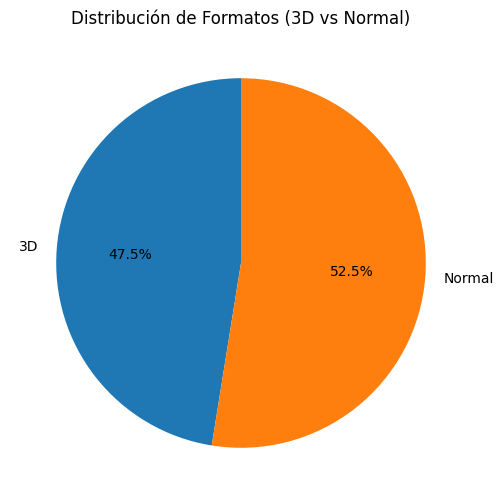

In [25]:
# Gráfico 1
plt.figure(figsize=(6, 6))
plt.pie(
    df_formato['cantidad'],
    labels=df_formato['formato'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribución de Formatos (3D vs Normal)')
plt.show()

In [26]:
conn = sqlite3.connect('warehouse.db')

df_genero = pd.read_sql("""
    SELECT genero, COUNT(*) AS total
    FROM ticket_sales
    GROUP BY genero
""", conn)

conn.close()

df_genero

,genero,total
0,F,514
1,M,493


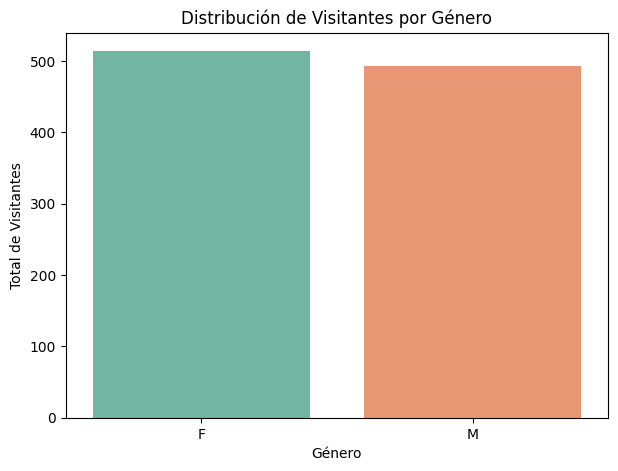

In [27]:
# Gráfico 2
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df_genero,
    x='genero',
    y='total',
    hue='genero',      # required to avoid the Seaborn warning
    palette='Set2',
    legend=False
)

plt.title('Distribución de Visitantes por Género')
plt.xlabel('Género')
plt.ylabel('Total de Visitantes')
plt.show()

In [28]:
conn = sqlite3.connect('warehouse.db')

df_gasto_genero = pd.read_sql("""
    SELECT genero, SUM(precio) AS total_gastado
    FROM ticket_sales
    GROUP BY genero
""", conn)

conn.close()

df_gasto_genero

,genero,total_gastado
0,F,4906.83
1,M,4706.91
